# LLM result check

## Note on Data Availability

The raw transcript (utterance) data is **not included** in this submission due to privacy and confidentiality constraints. 
The CSV files in `./data/` contain LLM classification results with the `utterance` column removed. 
Similarly, the human labeling data in `./human+labeling/` has been anonymized (labeler IDs: P1–P8) with utterance text removed.

To reproduce the full analysis pipeline, users must supply their own transcript data to the Python classification scripts (`llm.py`, `llm_api.py`).

In [21]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
import math

def compare_multiple_models(model_paths, model_names, combine_labels=True, exclude_teacher=True):   
    
    if len(model_paths) != len(model_names):
        raise ValueError("The lengths of model_paths and model_names must be the same.")
    
    if len(model_paths) < 2:
        raise ValueError("At least two models are required.")
        
    model_results = []
    series_list = []
    
    for i, (path, name) in enumerate(zip(model_paths, model_names)):
        try:
            df = pd.read_csv(path)
            print(f"{name} data load complete: {len(df)} samples")
        except FileNotFoundError:
            print(f"Error: {path} not found")
            continue
        
        if exclude_teacher and 'name' in df.columns:
            df = df[df.name != 'T'].reset_index(drop=True)
            print(f"Delete T utterance: {len(df)} samples")
        
        if combine_labels and 'llm_label' in df.columns and 'llm_engagement' in df.columns:
            df['combined_label'] = [
                l + ("" if pd.isna(e) else " (" + str(e) + ")") 
                for l, e in zip(df.llm_label, df.llm_engagement)
            ]
            label_column = 'combined_label'
        else:
            label_column = 'llm_label'
        
        series = pd.Series(df[label_column], name=f"{name} result")
        series_list.append(series)
        model_results.append(df)
    
    if len(series_list) < 2:
        print("At least two models are required.")
        return
    
    all_labels = sorted(list(set().union(*[s.unique() for s in series_list])))
    
    comparisons = list(combinations(series_list, 2))
    n_comparisons = len(comparisons)
    
    if n_comparisons <= 3:
        n_rows, n_cols = 1, n_comparisons
        figsize = (8 * n_comparisons, 7)
    elif n_comparisons <= 6:
        n_rows, n_cols = 2, math.ceil(n_comparisons / 2)
        figsize = (8 * n_cols, 7 * n_rows)
    else:
        n_rows, n_cols = 3, math.ceil(n_comparisons / 3)
        figsize = (8 * n_cols, 7 * n_rows)
        
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        
    if n_comparisons == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_comparisons > 1 else [axes]
    else:
        axes = axes.flatten()
    
    for i, (ser_a, ser_b) in enumerate(comparisons):
        name_a = ser_a.name
        name_b = ser_b.name
        
        min_len = min(len(ser_a), len(ser_b))
        ser_a_trimmed = ser_a.iloc[:min_len]
        ser_b_trimmed = ser_b.iloc[:min_len]
        
        cm = confusion_matrix(ser_a_trimmed, ser_b_trimmed, labels=all_labels)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=all_labels, yticklabels=all_labels,
                    ax=axes[i], cbar=(i == len(comparisons) - 1))

        axes[i].set_title(f'{name_a.split(" result")[0]} vs {name_b.split(" result")[0]}', fontsize=12)
        axes[i].set_xlabel(f'{name_b.split(" result")[0]}', fontsize=10)
        axes[i].set_ylabel(f'{name_a.split(" result")[0]}', fontsize=10)
        
        axes[i].tick_params(axis='x', rotation=45, labelsize=8) 
        axes[i].tick_params(axis='y', rotation=0, labelsize=8)

        accuracy = accuracy_score(ser_a_trimmed, ser_b_trimmed)
        kappa = cohen_kappa_score(ser_a_trimmed, ser_b_trimmed, labels=all_labels)

        print(f"--- {name_a.split(' result')[0]} vs {name_b.split(' result')[0]} ---")
        print(f"  Number of sample for comparison: {min_len}")
        print(f"  Agreement (Accuracy): {accuracy:.4f}")
        print(f"  Cohen's Kappa: {kappa:.4f}")
        print()
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f"LLM Comparison on Classification Task ({len(series_list)} Models)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    if len(series_list) >= 3:
        print("-" * 50)
        
        min_length = min([len(s) for s in series_list])
        trimmed_series = [s.iloc[:min_length] for s in series_list]
        
        all_agree_mask = pd.Series([True] * min_length)
        for i in range(1, len(trimmed_series)):
            all_agree_mask &= (trimmed_series[0] == trimmed_series[i])
        
        all_agree_count = all_agree_mask.sum()
        all_agree_ratio = all_agree_count / min_length
        
        print(f"Samples where all {len(series_list)} models agree:")
        print(f"  {all_agree_count} / {min_length} ({all_agree_ratio:.2%})")
        
        comparison_dict = {s.name.split(' result')[0]: s.iloc[:min_length] for s in series_list}
        comparison_dict['all model agree'] = all_agree_mask
        comparison_df = pd.DataFrame(comparison_dict)
        
        print("\n--- Label comparison per sample (Top 10) ---")
        print(comparison_df.head(10))
        
        print(f"\n--- Agreement check ---")
        for k in range(2, len(series_list)):
            partial_agreements = 0
            for combo in combinations(range(len(series_list)), k):
                agree_mask = pd.Series([True] * min_length)
                for i in range(1, len(combo)):
                    agree_mask &= (trimmed_series[combo[0]] == trimmed_series[combo[i]])
                partial_agreements = max(partial_agreements, agree_mask.sum())
            
            print(f"Predictions match for up to {k} models: {partial_agreements} / {min_length} ({partial_agreements/min_length:.2%})")
    
    return {
        'series_list': series_list,
        'all_labels': all_labels,
        'model_results': model_results,
        'comparison_results': comparisons
    }


model_paths = [
    "./data/openai_api_ver2_cleaned.csv",
    "./data/anthropic_api_ver2.csv",
    "./data/google_api_ver2.csv", 
    "./data/google_pro_api_ver2_128_system.csv",
    "./data/qwen3_results_final_ver2.csv",
    "./data/phi4_results_final_ver2.csv",
    "./data/llama_31_results_final_ver2.csv"
]

model_names = [
    "gpt4.1",
    "claude-sonnet4",
    "gemini-flash", 
    "gemini-pro", 
    "qwen3",
    "phi4",
    "llama3.1"
]

## Human labeling check

In [22]:
import os
import pandas as pd

h1_path = [os.getcwd() + "/human+labeling/" + f for f in os.listdir("./human+labeling/") if "DS" not in f]
h2_path = [[h1 + "/" + h2 for h2 in os.listdir(h1)] for h1 in h1_path]

data_by_labeler = {}
i = 1
for file_list in h2_path:
    try:
        first_path = file_list[0]
        labeler_dir = os.path.basename(os.path.dirname(first_path))
        labeler_name = "P" + str(i)
    except (IndexError, AttributeError):
        labeler_name = "Unknown_Labeler" 

    labeler_dataframes = []
    for file_path in file_list:
        try:
            df = pd.read_csv(file_path, encoding='utf-8-sig')
            df = df.reset_index(names="utterance_id")
            labeler_dataframes.append(df)
        except FileNotFoundError:
            print(f"Warning: File not found. Path: {file_path}")
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
    i += 1
    data_by_labeler[labeler_name] = labeler_dataframes

def simple_filter(df):
    df = df.copy().reset_index(drop=True)
    
    def get_students(group_name):
        return set(group_name.split())
    
    mask = []
    for i in range(len(df)):
        current = df.iloc[i]
        current_students = get_students(current['group'])
    
        if current['name'] == 'T' or current['name'] not in current_students:
            mask.append(False)
            continue
    
        if i == 0:
            mask.append(False) 
        else:
            prev = df.iloc[i-1]
            prev_students = get_students(prev['group'])
            if prev['name'] == 'T' or prev['name'] not in prev_students:
                mask.append(False)
            else:
                mask.append(True)
    
    return df[mask].reset_index(drop=True)

df_list = [
    pd.concat(data_by_labeler[f"P{i}"]).sort_values(["date","utterance_id"]).reset_index(drop=True)
    for i in range(1, 9)
]

df_list = [simple_filter(data) for data in df_list]
df_list[0].loc[df_list[0].label == "UC or EXP","label"] = "Uncorrelated"    

In [23]:
import numpy as np
import pandas as pd
from statsmodels.stats.inter_rater import fleiss_kappa

label_column = 'label'  

def calc_fleiss_kappa(df_list, label_column):
    label_series = [df[label_column] for df in df_list]
    all_labels = set()
    for series in label_series:
        all_labels.update(series.dropna().unique())
    all_labels = sorted(list(all_labels))

    num_samples = len(df_list[0])
    num_labels = len(all_labels)
    counts_matrix = np.zeros((num_samples, num_labels), dtype=int)

    label_to_idx = {label: i for i, label in enumerate(all_labels)}

    for sample_idx in range(num_samples):
        for df in df_list:
            label = df[label_column].iloc[sample_idx]
            if pd.notna(label) and label in label_to_idx:
                counts_matrix[sample_idx, label_to_idx[label]] += 1

    kappa_value = fleiss_kappa(counts_matrix, method='fleiss')
    return kappa_value

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.metrics import cohen_kappa_score

def calc_cohens_kappa(df1, df2, label_column):
    labels1 = df1[label_column]
    labels2 = df2[label_column]
    
    if len(labels1) != len(labels2):
        raise ValueError("The lengths of the two dataframes are different.")
    
    valid_mask = pd.notna(labels1) & pd.notna(labels2)
    labels1_clean = labels1[valid_mask]
    labels2_clean = labels2[valid_mask]
    
    if len(labels1_clean) == 0:
        raise ValueError("Invalid data")
    
    kappa_value = cohen_kappa_score(labels1_clean, labels2_clean)
    return kappa_value

def create_kappa_matrix(df_list, label_column='label', mlist=None):
    n_participants = len(df_list)
    
    kappa_matrix = np.full((n_participants, n_participants), np.nan)
    np.fill_diagonal(kappa_matrix, 1.0)
    
    for i, j in combinations(range(n_participants), 2):
        try:
            kappa_value = calc_cohens_kappa(df_list[i], df_list[j], label_column)
            kappa_matrix[i, j] = kappa_value
            kappa_matrix[j, i] = kappa_value
            participant_i = mlist[i] if mlist else f"Participant_{i}"
            participant_j = mlist[j] if mlist else f"Participant_{j}"
            print(f"{participant_i} vs {participant_j}: {kappa_value:.4f}")
        except Exception as e:
            participant_i = mlist[i] if mlist else f"Participant_{i}"
            participant_j = mlist[j] if mlist else f"Participant_{j}"
            print(f"{participant_i} vs {participant_j}: Error - {e}")
            kappa_matrix[i, j] = np.nan
            kappa_matrix[j, i] = np.nan
        
    if mlist:
        participant_labels = [f'{mlist[i]}' for i in range(n_participants)]
    else:
        participant_labels = [f'P{i+1}' for i in range(n_participants)]
    
    kappa_df = pd.DataFrame(kappa_matrix, 
                           index=participant_labels, 
                           columns=participant_labels)
    
    return kappa_df


def plot_kappa_matrix(kappa_df, title="Pairwise Cohen's Kappa Agreement Matrix",axislabel = "Participants"):
    
    plt.figure(figsize=(10, 8))    
    mask = np.isnan(kappa_df.values)  
    
    sns.heatmap(kappa_df, 
                annot=True,           
                fmt='.3f',           
                cmap='RdYlBu_r',     
                center=0.5,          
                vmin=0, vmax=1,      
                square=True,         
                cbar_kws={'label': "Cohen Kappa"},
                mask=mask)           
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(axislabel, fontsize=12)
    plt.ylabel(axislabel, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return plt.gcf()

def analyze_kappa_matrix(kappa_df):
    
    participant_means = {}
    for participant in kappa_df.index:        
        others = kappa_df.loc[participant].drop(participant)
        mean_kappa = others.mean()
        participant_means[participant] = mean_kappa
        print(f"{participant}: {mean_kappa:.3f}")
        
    print("\n=== Top 5 Agreement pair ===")
    pairs = []
    for i in range(len(kappa_df)):
        for j in range(i+1, len(kappa_df)):
            value = kappa_df.iloc[i, j]
            if not np.isnan(value):
                pairs.append((kappa_df.index[i], kappa_df.columns[j], value))
    
    pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
    for p1, p2, kappa in pairs_sorted[:5]:
        print(f"{p1} vs {p2}: {kappa:.3f}")
    
    print("\n=== Agreement distribution ===")
    all_values = [kappa for _, _, kappa in pairs]
    excellent = sum(1 for k in all_values if k > 0.8)
    good = sum(1 for k in all_values if 0.6 < k <= 0.8)
    moderate = sum(1 for k in all_values if 0.4 < k <= 0.6)
    fair = sum(1 for k in all_values if 0.2 < k <= 0.4)
    poor = sum(1 for k in all_values if k <= 0.2)
    
    print(f"Excellent (>0.8): {excellent}")
    print(f"Good (0.6-0.8): {good}")
    print(f"Moderate (0.4-0.6): {moderate}")
    print(f"Fair (0.2-0.4): {fair}")
    print(f"Poor (≤0.2): {poor}")
    
    return participant_means, pairs_sorted

Participant_0 vs Participant_1: 0.3815
Participant_0 vs Participant_2: 0.4982
Participant_0 vs Participant_3: 0.4261
Participant_0 vs Participant_4: 0.3362
Participant_0 vs Participant_5: 0.4728
Participant_0 vs Participant_6: 0.5704
Participant_0 vs Participant_7: 0.4510
Participant_1 vs Participant_2: 0.2975
Participant_1 vs Participant_3: 0.4315
Participant_1 vs Participant_4: 0.1903
Participant_1 vs Participant_5: 0.2417
Participant_1 vs Participant_6: 0.3965
Participant_1 vs Participant_7: 0.2411
Participant_2 vs Participant_3: 0.3358
Participant_2 vs Participant_4: 0.2230
Participant_2 vs Participant_5: 0.3655
Participant_2 vs Participant_6: 0.4862
Participant_2 vs Participant_7: 0.3933
Participant_3 vs Participant_4: 0.1557
Participant_3 vs Participant_5: 0.2911
Participant_3 vs Participant_6: 0.4489
Participant_3 vs Participant_7: 0.3589
Participant_4 vs Participant_5: 0.3193
Participant_4 vs Participant_6: 0.3205
Participant_4 vs Participant_7: 0.2336
Participant_5 vs Particip

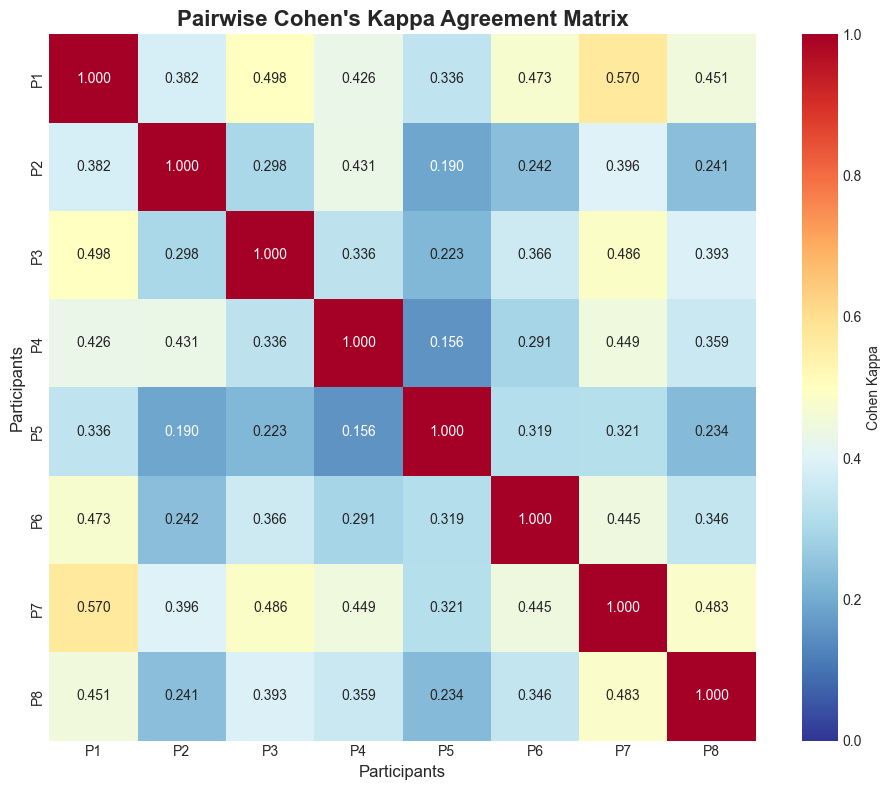

P1: 0.448
P2: 0.311
P3: 0.371
P4: 0.350
P5: 0.254
P6: 0.354
P7: 0.450
P8: 0.358

=== Top 5 Agreement pair ===
P1 vs P7: 0.570
P1 vs P3: 0.498
P3 vs P7: 0.486
P7 vs P8: 0.483
P1 vs P6: 0.473

=== Agreement distribution ===
Excellent (>0.8): 0
Good (0.6-0.8): 0
Moderate (0.4-0.6): 10
Fair (0.2-0.4): 16
Poor (≤0.2): 2


<Figure size 640x480 with 0 Axes>

In [25]:
kappa_matrix_df = create_kappa_matrix(df_list, 'label')
print(kappa_matrix_df.round(3))

off_diagonal = kappa_matrix_df.values[~np.eye(len(kappa_matrix_df), dtype=bool)]
off_diagonal = off_diagonal[~np.isnan(off_diagonal)]

print(f"Average: {np.mean(off_diagonal):.3f}")
print(f"Median: {np.median(off_diagonal):.3f}")
print(f"SD: {np.std(off_diagonal):.3f}")
print(f"Max: {np.max(off_diagonal):.3f}")
print(f"Min: {np.min(off_diagonal):.3f}")

plot_kappa_matrix(kappa_matrix_df)
participant_means, ranked_pairs = analyze_kappa_matrix(kappa_matrix_df)

In [26]:
mlist =  ["llama3.1","qwen3","phi4","gpt-4.1","cluade-4.0-sonnet","gemini-2.5-flash","gemini-2.5-pro"]
llm_path = ["llama_31_results_final_ver2.csv", "qwen3_results_final_ver2.csv",
            "phi4_results_final_ver2.csv","openai_api_ver2_cleaned.csv",
            "anthropic_api_ver2.csv", "google_api_ver2.csv",
            "google_pro_api_ver2_128_system.csv"]
llm_path = [os.getcwd() + "/data/" + l for l in llm_path]

filter_date = [1.22, 1.24, 3.24, 3.26, 5.28]
filter_group = ["Keila Delilah", "Isabel Shreen Julian William", "Armando Diego", "Natalie Esther Mya", "Daniel Gio Julian"]

date_group_pairs = [
    (1.22, "Keila Delilah"),
    (1.24, "Isabel Shreen Julian William"), 
    (3.24, "Armando Diego"),
    (3.26, "Natalie Esther Mya"),
    (5.28, "Daniel Gio Julian")
]

query_conditions = []
for date, group in date_group_pairs:
    query_conditions.append(f"(date == {date} and group == '{group}')")

query_string = " or ".join(query_conditions)

llm_data = []
for path in llm_path:
    df = pd.read_csv(path)
    filtered_df = df.query(query_string).reset_index(drop=True)
    llm_data.append(filtered_df)

def create_combined_label(df):
    df = df.copy()
    df['label'] = (
        df['llm_label'].fillna('') + 
        df['llm_engagement'].fillna('')
    )
    return df

for i in range(len(llm_data)):
    llm_data[i] = create_combined_label(llm_data[i])

def standardize_labels(df, label_column='label'):
    df = df.copy()
    label_mapping = {
        'Engage Others IdeaMEDIUM': 'Engage Others Idea (Medium)',
        'Engage Others IdeaLOW': 'Engage Others Idea (Low)', 
        'Engage Others IdeaHIGH': 'Engage Others Idea (High)',
        'Engage Others Idea_LOW': 'Engage Others Idea (Low)',
        'Engage Others Idea_MEDIUM': 'Engage Others Idea (Medium)',
        'Engage Others Idea_HIGH': 'Engage Others Idea (High)',
    }
    
    df[label_column] = df[label_column].replace(label_mapping)
    
    return df

filtered_llm_data = [simple_filter(data) for data in llm_data]
filtered_llm_data_l = [f.drop(f.index[96]).reset_index(drop=True) for f in filtered_llm_data]
filtered_llm_data_l = [standardize_labels(f) for f in filtered_llm_data_l]

llama3.1 vs qwen3: 0.4167
llama3.1 vs phi4: 0.4530
llama3.1 vs gpt-4.1: 0.3873
llama3.1 vs cluade-4.0-sonnet: 0.4025
llama3.1 vs gemini-2.5-flash: 0.4049
llama3.1 vs gemini-2.5-pro: 0.3644
qwen3 vs phi4: 0.4961
qwen3 vs gpt-4.1: 0.5808
qwen3 vs cluade-4.0-sonnet: 0.6184
qwen3 vs gemini-2.5-flash: 0.5110
qwen3 vs gemini-2.5-pro: 0.4571
phi4 vs gpt-4.1: 0.6048
phi4 vs cluade-4.0-sonnet: 0.5181
phi4 vs gemini-2.5-flash: 0.5038
phi4 vs gemini-2.5-pro: 0.5191
gpt-4.1 vs cluade-4.0-sonnet: 0.5904
gpt-4.1 vs gemini-2.5-flash: 0.6202
gpt-4.1 vs gemini-2.5-pro: 0.5935
cluade-4.0-sonnet vs gemini-2.5-flash: 0.5641
cluade-4.0-sonnet vs gemini-2.5-pro: 0.6060
gemini-2.5-flash vs gemini-2.5-pro: 0.5892
Average: 0.514
Median: 0.518
SD: 0.083
Max: 0.620
Min: 0.364


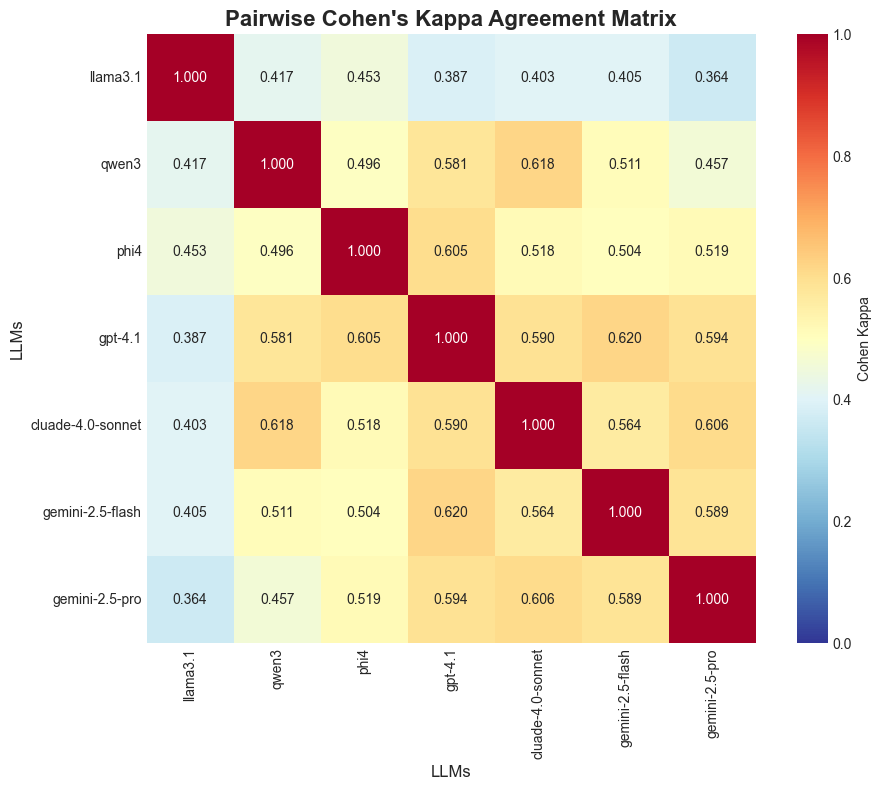

llama3.1: 0.405
qwen3: 0.513
phi4: 0.516
gpt-4.1: 0.563
cluade-4.0-sonnet: 0.550
gemini-2.5-flash: 0.532
gemini-2.5-pro: 0.522

=== Top 5 Agreement pair ===
gpt-4.1 vs gemini-2.5-flash: 0.620
qwen3 vs cluade-4.0-sonnet: 0.618
cluade-4.0-sonnet vs gemini-2.5-pro: 0.606
phi4 vs gpt-4.1: 0.605
gpt-4.1 vs gemini-2.5-pro: 0.594

=== Agreement distribution ===
Excellent (>0.8): 0
Good (0.6-0.8): 4
Moderate (0.4-0.6): 15
Fair (0.2-0.4): 2
Poor (≤0.2): 0


<Figure size 640x480 with 0 Axes>

In [27]:
kappa_matrix_df = create_kappa_matrix(filtered_llm_data_l, 'label', mlist)
off_diagonal = kappa_matrix_df.values[~np.eye(len(kappa_matrix_df), dtype=bool)]
off_diagonal = off_diagonal[~np.isnan(off_diagonal)]

print(f"Average: {np.mean(off_diagonal):.3f}")
print(f"Median: {np.median(off_diagonal):.3f}")
print(f"SD: {np.std(off_diagonal):.3f}")
print(f"Max: {np.max(off_diagonal):.3f}")
print(f"Min: {np.min(off_diagonal):.3f}")

plot_kappa_matrix(kappa_matrix_df, axislabel="LLMs")
participant_means, ranked_pairs = analyze_kappa_matrix(kappa_matrix_df)

In [28]:
filtered_llm_data_l_h = filtered_llm_data_l.copy()
mlist =  ["llama3.1","qwen3","phi4","gpt-4.1","cluade-4.0-sonnet","gemini-2.5-flash","gemini-2.5-pro"] + ["P" + str(i) for i in range(1,9)]
for i in range(8):
    filtered_llm_data_l_h.append(df_list[i])

llama3.1 vs qwen3: 0.4167
llama3.1 vs phi4: 0.4530
llama3.1 vs gpt-4.1: 0.3873
llama3.1 vs cluade-4.0-sonnet: 0.4025
llama3.1 vs gemini-2.5-flash: 0.4049
llama3.1 vs gemini-2.5-pro: 0.3644
llama3.1 vs P1: 0.3252
llama3.1 vs P2: 0.1952
llama3.1 vs P3: 0.2851
llama3.1 vs P4: 0.2258
llama3.1 vs P5: 0.2581
llama3.1 vs P6: 0.3343
llama3.1 vs P7: 0.3664
llama3.1 vs P8: 0.2839
qwen3 vs phi4: 0.4961
qwen3 vs gpt-4.1: 0.5808
qwen3 vs cluade-4.0-sonnet: 0.6184
qwen3 vs gemini-2.5-flash: 0.5110
qwen3 vs gemini-2.5-pro: 0.4571
qwen3 vs P1: 0.4425
qwen3 vs P2: 0.3298
qwen3 vs P3: 0.4515
qwen3 vs P4: 0.3938
qwen3 vs P5: 0.2597
qwen3 vs P6: 0.3581
qwen3 vs P7: 0.4583
qwen3 vs P8: 0.3105
phi4 vs gpt-4.1: 0.6048
phi4 vs cluade-4.0-sonnet: 0.5181
phi4 vs gemini-2.5-flash: 0.5038
phi4 vs gemini-2.5-pro: 0.5191
phi4 vs P1: 0.3408
phi4 vs P2: 0.2328
phi4 vs P3: 0.3635
phi4 vs P4: 0.2328
phi4 vs P5: 0.2790
phi4 vs P6: 0.3697
phi4 vs P7: 0.4241
phi4 vs P8: 0.2646
gpt-4.1 vs cluade-4.0-sonnet: 0.5904
gpt-4.1 

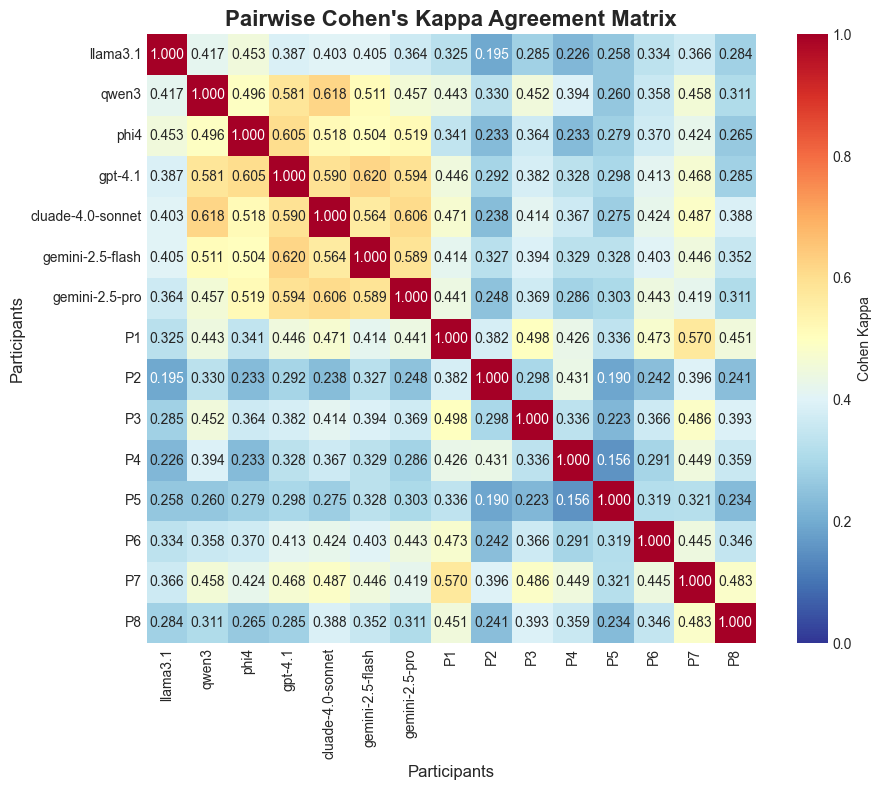

llama3.1: 0.336
qwen3: 0.435
phi4: 0.400
gpt-4.1: 0.449
cluade-4.0-sonnet: 0.454
gemini-2.5-flash: 0.442
gemini-2.5-pro: 0.425
P1: 0.430
P2: 0.289
P3: 0.376
P4: 0.329
P5: 0.270
P6: 0.373
P7: 0.444
P8: 0.336

=== Top 5 Agreement pair ===
gpt-4.1 vs gemini-2.5-flash: 0.620
qwen3 vs cluade-4.0-sonnet: 0.618
cluade-4.0-sonnet vs gemini-2.5-pro: 0.606
phi4 vs gpt-4.1: 0.605
gpt-4.1 vs gemini-2.5-pro: 0.594

=== Agreement distribution ===
Excellent (>0.8): 0
Good (0.6-0.8): 4
Moderate (0.4-0.6): 42
Fair (0.2-0.4): 56
Poor (≤0.2): 3


<Figure size 640x480 with 0 Axes>

In [29]:
kappa_matrix_df = create_kappa_matrix(filtered_llm_data_l_h, 'label',mlist)

off_diagonal = kappa_matrix_df.values[~np.eye(len(kappa_matrix_df), dtype=bool)]
off_diagonal = off_diagonal[~np.isnan(off_diagonal)]

print(f"Average: {np.mean(off_diagonal):.3f}")
print(f"Median: {np.median(off_diagonal):.3f}")
print(f"SD: {np.std(off_diagonal):.3f}")
print(f"Max: {np.max(off_diagonal):.3f}")
print(f"Min: {np.min(off_diagonal):.3f}")

plot_kappa_matrix(kappa_matrix_df)
participant_means, ranked_pairs = analyze_kappa_matrix(kappa_matrix_df)

llama3.1 vs P1: 0.3252
llama3.1 vs P2: 0.1952
llama3.1 vs P3: 0.2851
llama3.1 vs P4: 0.2258
llama3.1 vs P5: 0.2581
llama3.1 vs P6: 0.3343
llama3.1 vs P7: 0.3664
llama3.1 vs P8: 0.2839
qwen3 vs P1: 0.4425
qwen3 vs P2: 0.3298
qwen3 vs P3: 0.4515
qwen3 vs P4: 0.3938
qwen3 vs P5: 0.2597
qwen3 vs P6: 0.3581
qwen3 vs P7: 0.4583
qwen3 vs P8: 0.3105
phi4 vs P1: 0.3408
phi4 vs P2: 0.2328
phi4 vs P3: 0.3635
phi4 vs P4: 0.2328
phi4 vs P5: 0.2790
phi4 vs P6: 0.3697
phi4 vs P7: 0.4241
phi4 vs P8: 0.2646
gpt-4.1 vs P1: 0.4459
gpt-4.1 vs P2: 0.2918
gpt-4.1 vs P3: 0.3822
gpt-4.1 vs P4: 0.3282
gpt-4.1 vs P5: 0.2983
gpt-4.1 vs P6: 0.4127
gpt-4.1 vs P7: 0.4676
gpt-4.1 vs P8: 0.2850
cluade-4.0-sonnet vs P1: 0.4710
cluade-4.0-sonnet vs P2: 0.2380
cluade-4.0-sonnet vs P3: 0.4137
cluade-4.0-sonnet vs P4: 0.3666
cluade-4.0-sonnet vs P5: 0.2748
cluade-4.0-sonnet vs P6: 0.4244
cluade-4.0-sonnet vs P7: 0.4871
cluade-4.0-sonnet vs P8: 0.3876
gemini-2.5-flash vs P1: 0.4145
gemini-2.5-flash vs P2: 0.3269
gemini-2.5

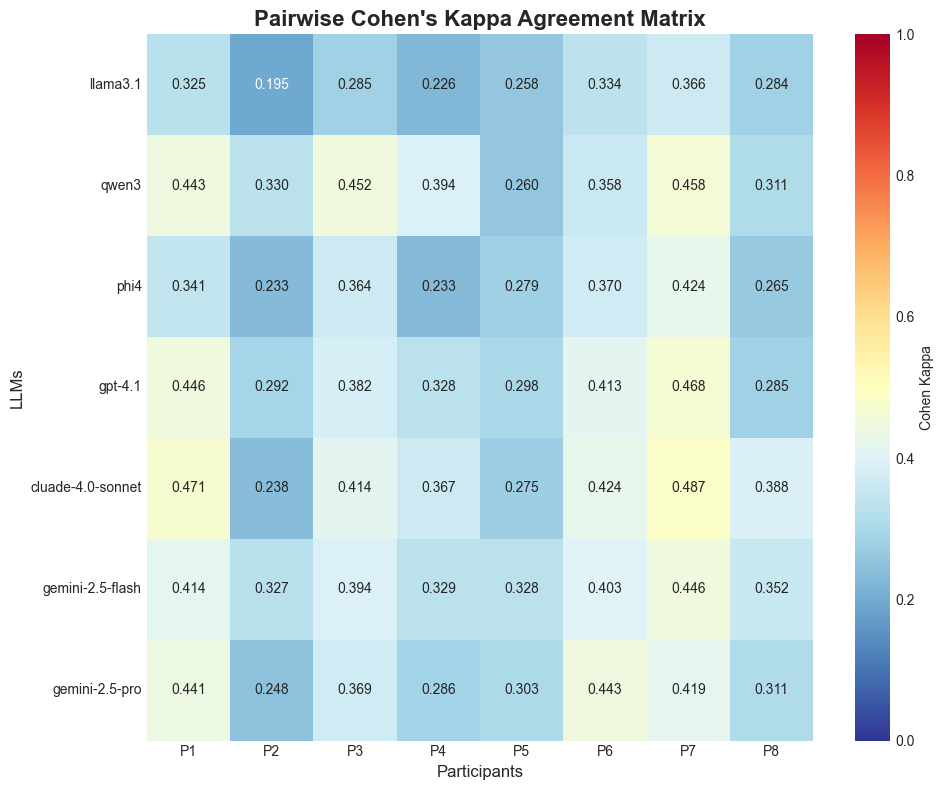

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [30]:
import numpy as np
import pandas as pd
from itertools import product

def create_asymmetric_kappa_matrix(df_list1, df_list2, label_column='label', mlist1=None, mlist2=None):
    n_participants1 = len(df_list1)
    n_participants2 = len(df_list2)  

    kappa_matrix = np.full((n_participants1, n_participants2), np.nan)
    for i, j in product(range(n_participants1), range(n_participants2)):
        try:
            kappa_value = calc_cohens_kappa(df_list1[i], df_list2[j], label_column)
            kappa_matrix[i, j] = kappa_value
            
            participant_i = mlist1[i] if mlist1 else f"Group1_{i}"
            participant_j = mlist2[j] if mlist2 else f"Group2_{j}"
            print(f"{participant_i} vs {participant_j}: {kappa_value:.4f}")
            
        except Exception as e:
            participant_i = mlist1[i] if mlist1 else f"Group1_{i}"
            participant_j = mlist2[j] if mlist2 else f"Group2_{j}"
            print(f"{participant_i} vs {participant_j}: Error - {e}")
            kappa_matrix[i, j] = np.nan
            
    if mlist1:
        participant_labels1 = [f'{mlist1[i]}' for i in range(n_participants1)]
    else:
        participant_labels1 = [f'G1_P{i+1}' for i in range(n_participants1)]
        
    if mlist2:
        participant_labels2 = [f'{mlist2[i]}' for i in range(n_participants2)]
    else:
        participant_labels2 = [f'G2_P{i+1}' for i in range(n_participants2)]
        
    kappa_df = pd.DataFrame(kappa_matrix,
                            index=participant_labels1,
                            columns=participant_labels2)
    
    return kappa_df

def plot_kappa_matrix(kappa_df, title="Pairwise Cohen's Kappa Agreement Matrix"):
    plt.figure(figsize=(10, 8))
    
    mask = np.isnan(kappa_df.values)  
    
    sns.heatmap(kappa_df, 
                annot=True,           
                fmt='.3f',           
                cmap='RdYlBu_r',     
                center=0.5,          
                vmin=0, vmax=1,      
                cbar_kws={'label': "Cohen Kappa", 'shrink': 1},
                mask=mask)           
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Participants", fontsize=12)
    plt.ylabel("LLMs", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return plt.gcf()


df_models = filtered_llm_data_l
mlist_models = ["llama3.1","qwen3","phi4","gpt-4.1","cluade-4.0-sonnet","gemini-2.5-flash","gemini-2.5-pro"] 
df_humans = df_list
mlist_humans = ["P" + str(i) for i in range(1,9)]

kappa_model_vs_human_df = create_asymmetric_kappa_matrix(
    df_models,
    df_humans,
    label_column='label',
    mlist1=mlist_models,
    mlist2=mlist_humans
)

plot_kappa_matrix(kappa_model_vs_human_df)

In [31]:
kappa_value = calc_fleiss_kappa(df_list, 'label')
print(f"Fleiss' Kappa: {kappa_value:.4f}")

Fleiss' Kappa: 0.3516


In [32]:
kappa_value = calc_fleiss_kappa(filtered_llm_data_l, 'label')
print(f"Fleiss' Kappa: {kappa_value:.4f}")

Fleiss' Kappa: 0.5070


In [33]:
kappa_value = calc_fleiss_kappa(filtered_llm_data_l[3:7], 'label')
print(f"Fleiss' Kappa: {kappa_value:.4f}")

Fleiss' Kappa: 0.5933


# Uncertainty quantification

In [34]:
import pandas as pd
import numpy as np

def calc_entropy_df(df, probability_columns):
    df['max_prob'] = df[probability_columns].max(axis=1)
    df['shannon_entropy'] = df[probability_columns].apply(calculate_shannon_entropy_row, axis=1)
    return df

def calculate_shannon_entropy_row(probabilities):    
    probabilities = probabilities[probabilities > 0]
    if probabilities.empty:
        return 0.0        
    # Shannon entropy: -Σ(p * log2(p))
    return -np.sum(probabilities * np.log2(probabilities))

In [35]:
llama_logit = pd.read_csv("./data/llama_31_logit_ver2.csv")
phi_logit = pd.read_csv("./data/phi4_logit_ver2.csv")
qwen_logit = pd.read_csv("./data/qwen3_logit_ver2.csv")

probability_columns = [
    'prob_explain_own_idea',
    'prob_engage_others_low',
    'prob_engage_others_medium',
    'prob_engage_others_high',
    'prob_uncorrelated'
]

llama_logit = calc_entropy_df(llama_logit, probability_columns)
phi_logit = calc_entropy_df(phi_logit, probability_columns)
qwen_logit = calc_entropy_df(qwen_logit, probability_columns)

In [36]:
def update_previous_speaker_reference(df):
    df = df.copy()
       
    for i in range(len(df)):
        if (df.loc[i, 'llm_label'] == 'Engage Others Idea' and 
            df.loc[i, 'llm_reference'] == 'Previous Speaker'):
            current_group = df.loc[i, 'group']
            current_date = df.loc[i, 'date']
            current_utterance_id = df.loc[i, 'utterance_id']

            prev_utterances = df[
                (df['group'] == current_group) & 
                (df['date'] == current_date) & 
                (df['utterance_id'] < current_utterance_id)
            ]
            
            if len(prev_utterances) > 0:
                prev_speaker = prev_utterances.iloc[-1]['name']
                if prev_speaker == df.loc[i, "name"]:
                    prev_speaker = "none"
                    df.loc[i, 'llm_reference'] = prev_speaker
                else:
                    df.loc[i, 'llm_reference'] = prev_speaker
            else:
                df.loc[i, 'llm_reference'] = "none"   
    
    return df

def update_teacher_related_utterances(df, delete=False):
    df = df.copy()
    indices_to_remove = set()
    teacher_indices = df[df['name'] == 'T'].index.tolist()
    
    if delete:
        indices_to_remove.update(teacher_indices)
    else:
        df.loc[df['name'] == 'T', 'llm_label'] = 'Uncorrelated'
    
    for i in teacher_indices:
        if i >= len(df):  
            continue
        current_group = df.loc[i, 'group']
        current_date = df.loc[i, 'date']
        current_utterance_id = df.loc[i, 'utterance_id']
                
        subsequent_utterances = df[
            (df['group'] == current_group) & 
            (df['date'] == current_date) & 
            (df['utterance_id'] > current_utterance_id)
        ].sort_values('utterance_id')
        
        if len(subsequent_utterances) > 0:
            next_utterance_idx = subsequent_utterances.index[0]
            
            if delete:
                indices_to_remove.add(next_utterance_idx)
            else:
                df.loc[next_utterance_idx, 'llm_label'] = 'Uncorrelated'
        
    if delete and indices_to_remove:
        df = df.drop(list(indices_to_remove)).reset_index(drop=True)
    
    return df

def get_dataset(path, mod = "llama", logit = False, delete = False):
    data = pd.read_csv(path)
    name_list = set((" ".join(data.group.unique())).split(" ") + ["T"])
    data = data[data.name.isin(name_list)].reset_index(drop=True)

    data.llm_reference = data['llm_reference'].str.replace('**', '')
    data.llm_reference = data['llm_reference'].str.replace('NA', 'none')
    data.llm_reference = data['llm_reference'].str.replace(r'\s*\([^)]*\)', '', regex=True)
    data.name = data['name'].str.replace(r'\s*\([^)]*\)', '', regex=True)
    data.name = data['name'].str.replace('Jullian', 'Julian')
    data.name = data['name'].str.replace('Teacher', 'T')   

    data = update_previous_speaker_reference(data)
    print(f"Previous Speaker references updated")

    data = update_teacher_related_utterances(data, delete)
    print(f"Teacher-related utterances updated to Uncorrelated")

    data = data.sort_values(by=["date","group","block_index"], ascending=[True, True, True]).reset_index(drop=True)
    data['label'] = data['llm_label'].str.lower().fillna('none')
    data['level'] = data['llm_engagement'].str.lower().fillna('none')
    data['reference'] = data['llm_reference'].str.lower().fillna('none')
    data['group'] = data['group'].str.lower()
    data['name'] = data['name'].str.lower()
    data["group_size"] = [len(g.split(" ")) for g in data.group]
 
    if logit:
        data = data.loc[:,["name","date","timestamp","label","level","reference","group","group_size",
                           "tokprob_explain_own_idea","tokprob_engage_others","tokprob_uncorrelated",
                           "tokprob_engage_low","tokprob_engage_medium","tokprob_engage_high",
                           "prob_explain_own_idea","prob_engage_others_low","prob_engage_others_medium","prob_engage_others_high","prob_uncorrelated"]]
    else:
        data = data.loc[:,["name","date","timestamp","label","level","reference","group","group_size"]]

    data.loc[data['label'] != 'engage others idea', 'level'] = 'none'

    return data

Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
All data loaded and processed successfully.
Total predictions: 12699
Filtered uncertain predictions (max_prob < 0.99): 753


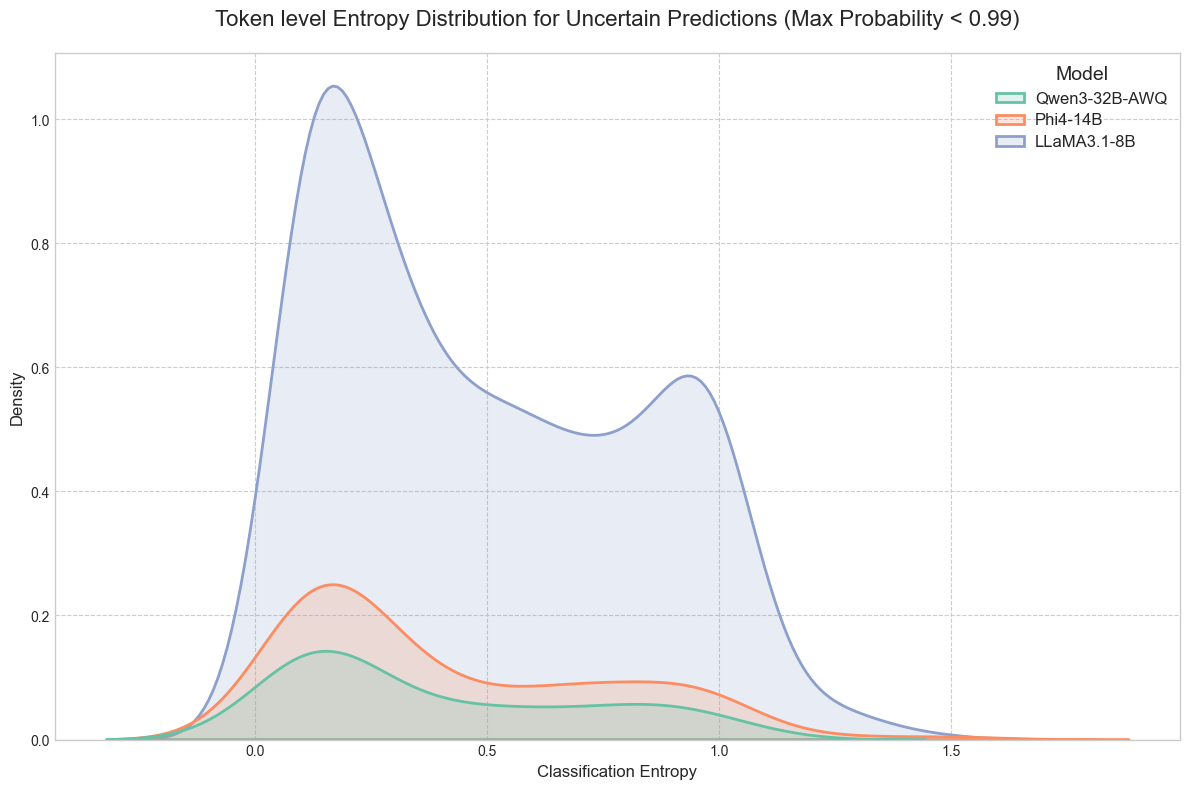

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_uncertainty_and_max_prob(df, model_name):
    """
    Calculates entropy and max probability, and adds a model name column.
    """
    # Define probability columns
    prob_cols = [
        "tokprob_explain_own_idea","tokprob_engage_others","tokprob_uncorrelated"
    ]
    
    # Calculate classification entropy: H = -sum(p * log2(p))
    probs = df[prob_cols].values
    epsilon = 1e-9 # Add a small epsilon to prevent log2(0)
    entropy = -np.sum(probs * np.log2(probs + epsilon), axis=1)
    df['entropy'] = entropy
    
    # Calculate the maximum probability for each prediction
    df['max_probability'] = df[prob_cols].max(axis=1)
    
    df['model'] = model_name
    
    return df

# --- Data Loading and Preprocessing ---
try:
    # Load all three model data files
    # llama_df = pd.read_csv('./data/llama_31_logit_ver2.csv')
    # phi_df = pd.read_csv('./data/phi4_logit_ver2.csv')
    # qwen_df = pd.read_csv('./data/qwen3_logit_ver2.csv')

    llama_df = get_dataset("./data/llama_31_logit_ver2.csv","llama",True,False)
    phi_df = get_dataset("./data/phi4_logit_ver2.csv","phi",True,False)
    qwen_df = get_dataset("./data/qwen3_logit_ver2.csv","qwen",True,False)

    # Calculate uncertainty metrics for each model
    llama_df = calculate_uncertainty_and_max_prob(llama_df, 'LLaMA3.1-8B')
    phi_df = calculate_uncertainty_and_max_prob(phi_df, 'Phi4-14B')
    qwen_df = calculate_uncertainty_and_max_prob(qwen_df, 'Qwen3-32B-AWQ')

    # Combine all dataframes into a single one
    combined_df = pd.concat([qwen_df,phi_df,llama_df], ignore_index=True)
    
    # --- Filter for uncertain cases ---
    # Keep only the rows where the model was not highly confident in any single choice
    prob_limit = 0.99
    uncertain_df = combined_df[combined_df['max_probability'] <= prob_limit].copy()
    
    print("All data loaded and processed successfully.")
    print(f"Total predictions: {len(combined_df)}")
    print(f"Filtered uncertain predictions (max_prob < {prob_limit}): {len(uncertain_df)}")

    # --- Visualization: Overlapping Density Plots for Uncertain Cases ---
    plt.style.use('seaborn-v0_8-whitegrid')
    
    plt.figure(figsize=(12, 8))
    my_order = ['Qwen3-32B-AWQ','Phi4-14B','LLaMA3.1-8B']
    my_colors = sns.color_palette('Set2', 3)
    my_palette = {
        'LLaMA3.1-8B': my_colors[2],
        'Phi4-14B': my_colors[1],
        'Qwen3-32B-AWQ': my_colors[0]
    }
    # Use kdeplot for a smooth density representation
    ax = sns.kdeplot(
        data=uncertain_df, 
        x='entropy', 
        hue='model', 
        palette=my_palette, 
        fill=True,      # Fill the area under the curve
        alpha=0.2,      # Use transparency to see overlaps
        linewidth=2,
        common_norm=True,
        legend=True
    )
   
    plt.title(f'Token level Entropy Distribution for Uncertain Predictions (Max Probability < {prob_limit})', fontsize=16, pad=20)
    plt.xlabel('Classification Entropy', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.grid(True, which="both", ls="--")
    
    # --- Adjust Legend Properties ---
    legend = ax.get_legend()
    legend.set_title('Model')
    plt.setp(legend.get_title(), fontsize='14') # Set title font size
    plt.setp(legend.get_texts(), fontsize='12') # Set item label font size
    
    plt.tight_layout()
    plt.show() # Uncomment to display plot in a local environment

except FileNotFoundError as e:
    print(f"File Error: {e}. Please ensure all CSV files are in the same directory.")
except Exception as e:
    print(f"An error occurred during script execution: {e}")

Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
All data loaded and processed successfully.
Total predictions: 12699
Filtered uncertain predictions (max_prob < 0.99): 7426


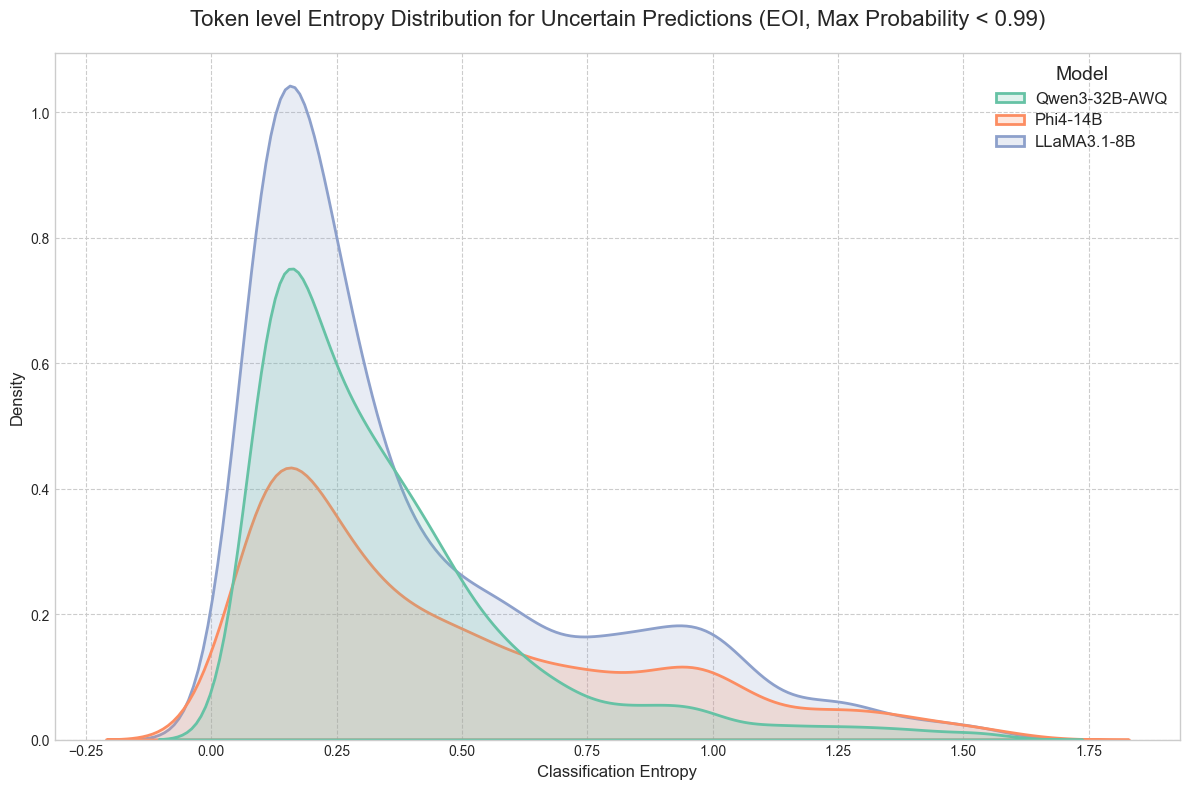

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_uncertainty_and_max_prob(df, model_name):
    """
    Calculates entropy and max probability, and adds a model name column.
    """
    # Define probability columns
    prob_cols = ['tokprob_engage_low','tokprob_engage_medium', 'tokprob_engage_high']
    
    # Calculate classification entropy: H = -sum(p * log2(p))
    probs = df[prob_cols].values
    epsilon = 1e-9 # Add a small epsilon to prevent log2(0)
    entropy = -np.sum(probs * np.log2(probs + epsilon), axis=1)
    df['entropy'] = entropy
    
    # Calculate the maximum probability for each prediction
    df['max_probability'] = df[prob_cols].max(axis=1)
    
    df['model'] = model_name
    
    return df

# --- Data Loading and Preprocessing ---
try:
    # Load all three model data files
    # llama_df = pd.read_csv('./data/llama_31_logit_ver2.csv')
    # phi_df = pd.read_csv('./data/phi4_logit_ver2.csv')
    # qwen_df = pd.read_csv('./data/qwen3_logit_ver2.csv')

    llama_df = get_dataset("./data/llama_31_logit_ver2.csv","llama",True,False)
    phi_df = get_dataset("./data/phi4_logit_ver2.csv","phi",True,False)
    qwen_df = get_dataset("./data/qwen3_logit_ver2.csv","qwen",True,False)

    # Calculate uncertainty metrics for each model
    llama_df = calculate_uncertainty_and_max_prob(llama_df, 'LLaMA3.1-8B')
    phi_df = calculate_uncertainty_and_max_prob(phi_df, 'Phi4-14B')
    qwen_df = calculate_uncertainty_and_max_prob(qwen_df, 'Qwen3-32B-AWQ')

    # Combine all dataframes into a single one
    combined_df = pd.concat([qwen_df,phi_df,llama_df], ignore_index=True)
    
    # --- Filter for uncertain cases ---
    # Keep only the rows where the model was not highly confident in any single choice
    prob_limit = 0.99
    uncertain_df = combined_df[combined_df['max_probability'] <= prob_limit].copy()
    
    print("All data loaded and processed successfully.")
    print(f"Total predictions: {len(combined_df)}")
    print(f"Filtered uncertain predictions (max_prob < {prob_limit}): {len(uncertain_df)}")

    # --- Visualization: Overlapping Density Plots for Uncertain Cases ---
    plt.style.use('seaborn-v0_8-whitegrid')
    
    plt.figure(figsize=(12, 8))
    my_order = ['Qwen3-32B-AWQ','Phi4-14B','LLaMA3.1-8B']
    my_colors = sns.color_palette('Set2', 3)
    my_palette = {
        'LLaMA3.1-8B': my_colors[2],
        'Phi4-14B': my_colors[1],
        'Qwen3-32B-AWQ': my_colors[0]
    }
    # Use kdeplot for a smooth density representation
    ax = sns.kdeplot(
        data=uncertain_df, 
        x='entropy', 
        hue='model', 
        palette=my_palette, 
        fill=True,      # Fill the area under the curve
        alpha=0.2,      # Use transparency to see overlaps
        linewidth=2,
        common_norm=True,
        legend=True
    )
   
    plt.title(f'Token level Entropy Distribution for Uncertain Predictions (EOI, Max Probability < {prob_limit})', fontsize=16, pad=20)
    plt.xlabel('Classification Entropy', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.grid(True, which="both", ls="--")
    
    # --- Adjust Legend Properties ---
    legend = ax.get_legend()
    legend.set_title('Model')
    plt.setp(legend.get_title(), fontsize='14') # Set title font size
    plt.setp(legend.get_texts(), fontsize='12') # Set item label font size
    
    plt.tight_layout()
    plt.show() # Uncomment to display plot in a local environment

except FileNotFoundError as e:
    print(f"File Error: {e}. Please ensure all CSV files are in the same directory.")
except Exception as e:
    print(f"An error occurred during script execution: {e}")

Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
All data loaded and processed successfully.
Total 'Engage' predictions: 3489
Filtered uncertain predictions (max_prob <= 0.99): 1557


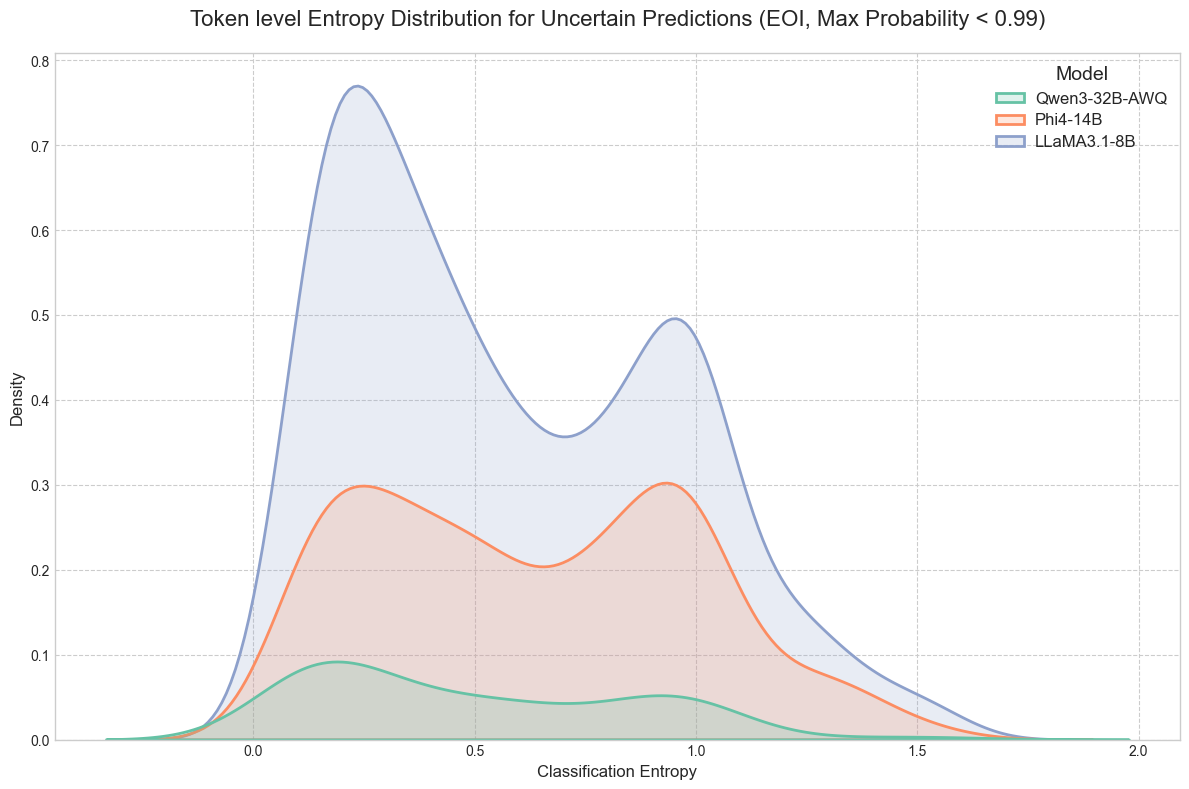

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_uncertainty_and_max_prob(df, model_name):
    """
    Filters for 'Engage' class, normalizes specific engagement probabilities, 
    and calculates both entropy and max probability correctly.
    """
    # 1. Identify primary prediction category (Explain vs Engage vs Uncorrelated)
    prob_cols_primary = ['tokprob_explain_own_idea', 'tokprob_engage_others', 'tokprob_uncorrelated']
    df['primary_pred'] = df[prob_cols_primary].idxmax(axis=1)
    
    # 2. Filter and copy only cases where the primary prediction is 'Engage Others'
    df_engage = df[df['primary_pred'] == 'tokprob_engage_others'].copy()
    
    # 3. Extract and normalize sub-category engagement probabilities (so they sum to 1)
    prob_cols_engage = ['tokprob_engage_low', 'tokprob_engage_medium', 'tokprob_engage_high']
    probs_engage = df_engage[prob_cols_engage].values
    epsilon = 1e-9 # Small value to prevent log2(0) error
    
    prob_sums = probs_engage.sum(axis=1, keepdims=True)
    probs_engage_norm = probs_engage / (prob_sums + epsilon)
    
    # 4. Calculate entropy and maximum probability based on the normalized values
    entropy = -np.sum(probs_engage_norm * np.log2(probs_engage_norm + epsilon), axis=1)
    df_engage['entropy'] = entropy
    df_engage['max_probability'] = probs_engage_norm.max(axis=1)
    
    df_engage['model'] = model_name
    
    return df_engage

# --- Data Loading and Preprocessing ---
try:
    # Load all three model data files with predefined function
    llama_df = get_dataset("./data/llama_31_logit_ver2.csv", "llama", True, False)
    phi_df = get_dataset("./data/phi4_logit_ver2.csv", "phi", True, False)
    qwen_df = get_dataset("./data/qwen3_logit_ver2.csv", "qwen", True, False)

    # Calculate uncertainty metrics for each model (only Engage subset is returned)
    llama_engage = calculate_uncertainty_and_max_prob(llama_df, 'LLaMA3.1-8B')
    phi_engage = calculate_uncertainty_and_max_prob(phi_df, 'Phi4-14B')
    qwen_engage = calculate_uncertainty_and_max_prob(qwen_df, 'Qwen3-32B-AWQ')

    # Combine all filtered dataframes into a single one
    combined_df = pd.concat([qwen_engage, phi_engage, llama_engage], ignore_index=True)
    
    # --- Filter for uncertain cases ---
    # (Filter tokens classified as 'Engage' where the sub-prediction confidence is 99% or less)
    prob_limit = 0.99
    uncertain_df = combined_df[combined_df['max_probability'] <= prob_limit].copy()
    
    print("All data loaded and processed successfully.")
    print(f"Total 'Engage' predictions: {len(combined_df)}")
    print(f"Filtered uncertain predictions (max_prob <= {prob_limit}): {len(uncertain_df)}")

    # --- Visualization: Overlapping Density Plots for Uncertain Cases ---
    plt.style.use('seaborn-v0_8-whitegrid')
    
    plt.figure(figsize=(12, 8))
    my_order = ['Qwen3-32B-AWQ', 'Phi4-14B', 'LLaMA3.1-8B']
    my_colors = sns.color_palette('Set2', 3)
    my_palette = {
        'LLaMA3.1-8B': my_colors[2],
        'Phi4-14B': my_colors[1],
        'Qwen3-32B-AWQ': my_colors[0]
    }
    
    # Use kdeplot for a smooth density representation
    ax = sns.kdeplot(
        data=uncertain_df, 
        x='entropy', 
        hue='model', 
        palette=my_palette, 
        fill=True,      
        alpha=0.2,      
        linewidth=2,
        common_norm=True,
        legend=True
    )
   
    plt.title(f'Token level Entropy Distribution for Uncertain Predictions (EOI, Max Probability < {prob_limit})', fontsize=16, pad=20)
    plt.xlabel('Classification Entropy', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.grid(True, which="both", ls="--")
    
    # --- Adjust Legend Properties ---
    legend = ax.get_legend()
    legend.set_title('Model')
    plt.setp(legend.get_title(), fontsize='14') 
    plt.setp(legend.get_texts(), fontsize='12') 
    
    plt.tight_layout()
    plt.show() 

except FileNotFoundError as e:
    print(f"File Error: {e}. Please ensure all CSV files are in the same directory.")
except Exception as e:
    print(f"An error occurred during script execution: {e}")

Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
Previous Speaker references updated
Teacher-related utterances updated to Uncorrelated
All data loaded and processed successfully.
Total predictions: 12699
Filtered uncertain predictions (max_prob < 0.99): 2200


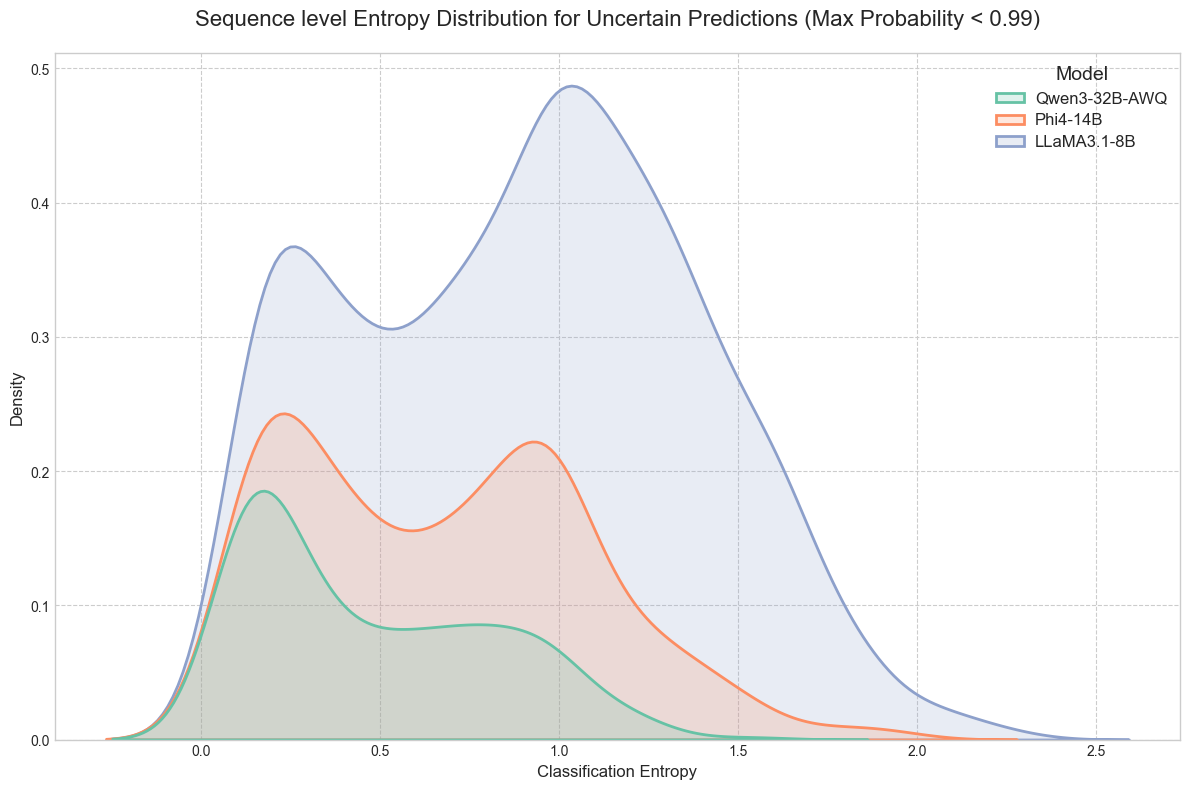

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_uncertainty_and_max_prob(df, model_name):
    """
    Calculates entropy and max probability, and adds a model name column.
    """
    # Define probability columns
    prob_cols = [
        'prob_explain_own_idea', 'prob_engage_others_low',
        'prob_engage_others_medium', 'prob_engage_others_high', 'prob_uncorrelated'
    ]
    
    # Calculate classification entropy: H = -sum(p * log2(p))
    probs = df[prob_cols].values
    epsilon = 1e-9 # Add a small epsilon to prevent log2(0)
    entropy = -np.sum(probs * np.log2(probs + epsilon), axis=1)
    df['entropy'] = entropy
    
    # Calculate the maximum probability for each prediction
    df['max_probability'] = df[prob_cols].max(axis=1)
    
    df['model'] = model_name
    
    return df

# --- Data Loading and Preprocessing ---
try:
    # Load all three model data files
    # llama_df = pd.read_csv('./data/llama_31_logit_ver2.csv')
    # phi_df = pd.read_csv('./data/phi4_logit_ver2.csv')
    # qwen_df = pd.read_csv('./data/qwen3_logit_ver2.csv')

    llama_df = get_dataset("./data/llama_31_logit_ver2.csv","llama",True,False)
    phi_df = get_dataset("./data/phi4_logit_ver2.csv","phi",True,False)
    qwen_df = get_dataset("./data/qwen3_logit_ver2.csv","qwen",True,False)

    # Calculate uncertainty metrics for each model
    llama_df = calculate_uncertainty_and_max_prob(llama_df, 'LLaMA3.1-8B')
    phi_df = calculate_uncertainty_and_max_prob(phi_df, 'Phi4-14B')
    qwen_df = calculate_uncertainty_and_max_prob(qwen_df, 'Qwen3-32B-AWQ')

    # Combine all dataframes into a single one
    combined_df = pd.concat([qwen_df,phi_df,llama_df], ignore_index=True)
    
    # --- Filter for uncertain cases ---
    # Keep only the rows where the model was not highly confident in any single choice
    prob_limit = 0.99
    uncertain_df = combined_df[combined_df['max_probability'] <= prob_limit].copy()
    
    print("All data loaded and processed successfully.")
    print(f"Total predictions: {len(combined_df)}")
    print(f"Filtered uncertain predictions (max_prob < {prob_limit}): {len(uncertain_df)}")


    # --- Visualization: Overlapping Density Plots for Uncertain Cases ---
    plt.style.use('seaborn-v0_8-whitegrid')
    
    plt.figure(figsize=(12, 8))
    
    # Use kdeplot for a smooth density representation
    ax = sns.kdeplot(
        data=uncertain_df, 
        x='entropy', 
        hue='model', 
        palette='Set2', 
        fill=True,      # Fill the area under the curve
        alpha=0.2,      # Use transparency to see overlaps
        linewidth=2,
        common_norm=True
    )
    
    plt.title(f'Sequence level Entropy Distribution for Uncertain Predictions (Max Probability < {prob_limit})', fontsize=16, pad=20)
    plt.xlabel('Classification Entropy', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    
    plt.grid(True, which="both", ls="--")
    
    # --- Adjust Legend Properties ---
    # Get the legend object from the axes
    legend = ax.get_legend()
    # Set the title for the legend
    legend.set_title('Model')
    # Set the font size for the legend title and labels
    plt.setp(legend.get_title(), fontsize='14') # Set title font size
    plt.setp(legend.get_texts(), fontsize='12') # Set item label font size
    
    plt.tight_layout()
    plt.show() # Uncomment to display plot in a local environment

except FileNotFoundError as e:
    print(f"File Error: {e}. Please ensure all CSV files are in the same directory.")
except Exception as e:
    print(f"An error occurred during script execution: {e}")